# YAMNet Inference

This notebook is fully self-contained for Google Colab and runs inference on the unseen rows from `wolfset_test.csv` using the saved artifacts from the final training notebook.


In [1]:
!pip -q install "setuptools<81" tensorflow tensorflow-hub librosa scikit-learn pandas seaborn matplotlib scipy joblib tqdm

In [2]:
from pathlib import Path
import json


try:
    from google.colab import drive
    drive.mount("/content/drive")
except ImportError:
    print("Google Colab not detected. If you are running locally, update PROJECT_ROOT below.")


PROJECT_ROOT = Path("/content/drive/MyDrive/1:1_Arjan_Walia/Vessels")  # Update this if your Drive path is different.
TEST_CSV = PROJECT_ROOT / "datasets"/ "processed_files" / "wolfset_test.csv"
AUDIO_DIR = PROJECT_ROOT / "datasets" / "25791978"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts"
EMBEDDING_CACHE_DIR = ARTIFACT_DIR / "yamnet_embeddings_test_5s"
TFHUB_CACHE_DIR = ARTIFACT_DIR / "tfhub_cache"
MODEL_PATH = ARTIFACT_DIR / "yamnet_classifier.keras"
SCALER_PATH = ARTIFACT_DIR / "yamnet_scaler.joblib"
LABEL_METADATA_PATH = ARTIFACT_DIR / "label_metadata.json"
TRAINING_CONFIG_PATH = ARTIFACT_DIR / "yamnet_training_config.json"
PREDICTIONS_PATH = ARTIFACT_DIR / "test_predictions.csv"
METRICS_PATH = ARTIFACT_DIR / "test_metrics.json"

assert TEST_CSV.exists(), f"Could not find: {TEST_CSV}"
assert AUDIO_DIR.exists(), f"Could not find: {AUDIO_DIR}"
assert MODEL_PATH.exists(), f"Could not find saved model: {MODEL_PATH}"

training_config = json.loads(TRAINING_CONFIG_PATH.read_text())
TARGET_SAMPLE_RATE = int(training_config["target_sample_rate"])
CLIP_DURATION_SECONDS = float(training_config["clip_duration_seconds"])

Mounted at /content/drive


In [3]:
import json
import os
import random
from itertools import product
from pathlib import Path

import joblib
import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import tensorflow_hub as hub
from IPython.display import display
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from tqdm.auto import tqdm

CLASS_NAME_MAP = {
    1: "4.5hp",
    2: "18hp",
    3: "8hp",
    4: "3.6hp",
    5: "Electric",
}


def load_split_dataframe(csv_path: Path, audio_dir: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path).copy()
    df["label"] = df["label"].astype(int)
    df["audio_path"] = df["filename"].map(lambda name: str((audio_dir / name).resolve()))
    missing = [name for name, path in zip(df["filename"], df["audio_path"]) if not Path(path).exists()]
    if missing:
        raise FileNotFoundError(f"Missing {len(missing)} audio files. First few: {missing[:5]}")
    return df.reset_index(drop=True)


def load_waveform(audio_path: str, target_sample_rate: int = 16000, clip_duration_seconds: float = 5.0) -> np.ndarray:
    waveform, _ = librosa.load(audio_path, sr=target_sample_rate, mono=True, duration=clip_duration_seconds)
    waveform = waveform.astype(np.float32)
    peak = np.max(np.abs(waveform))
    if peak > 0:
        waveform = waveform / peak
    return waveform


def load_yamnet_model(cache_dir: Path):
    cache_dir.mkdir(parents=True, exist_ok=True)
    os.environ["TFHUB_CACHE_DIR"] = str(cache_dir)
    return hub.load("https://tfhub.dev/google/yamnet/1")


def extract_yamnet_embedding(audio_path: str, yamnet_model, target_sample_rate: int = 16000, clip_duration_seconds: float = 5.0) -> np.ndarray:
    waveform = load_waveform(audio_path, target_sample_rate=target_sample_rate, clip_duration_seconds=clip_duration_seconds)
    _, embeddings, _ = yamnet_model(waveform)
    return np.mean(embeddings.numpy(), axis=0).astype(np.float32)


def build_embedding_matrix(
    metadata: pd.DataFrame,
    yamnet_model,
    cache_dir: Path,
    target_sample_rate: int = 16000,
    clip_duration_seconds: float = 5.0,
) -> tuple[pd.DataFrame, np.ndarray]:
    cache_dir.mkdir(parents=True, exist_ok=True)
    rows = []
    embeddings = []

    for _, row in tqdm(metadata.iterrows(), total=len(metadata), desc="YAMNet embeddings"):
        cache_name = f"{Path(row['filename']).stem}_sr{target_sample_rate}_{clip_duration_seconds:g}s.npy"
        cache_path = cache_dir / cache_name

        if cache_path.exists():
            embedding = np.load(cache_path)
        else:
            embedding = extract_yamnet_embedding(
                audio_path=row["audio_path"],
                yamnet_model=yamnet_model,
                target_sample_rate=target_sample_rate,
                clip_duration_seconds=clip_duration_seconds,
            )
            np.save(cache_path, embedding)

        rows.append(row)
        embeddings.append(embedding.astype(np.float32))

    return pd.DataFrame(rows).reset_index(drop=True), np.vstack(embeddings).astype(np.float32)


def build_classifier(input_dim: int, num_classes: int, learning_rate: float, dropout_rate: float = 0.30) -> tf.keras.Model:
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(256, activation="relu"),
        tf.keras.layers.Dropout(dropout_rate),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dropout(dropout_rate / 2.0),
        tf.keras.layers.Dense(num_classes, activation="softmax"),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def compute_class_weight_dict(y_encoded: np.ndarray) -> dict[int, float]:
    classes = np.unique(y_encoded)
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_encoded)
    return {int(cls): float(weight) for cls, weight in zip(classes, weights)}

In [4]:
test_df = load_split_dataframe(TEST_CSV, AUDIO_DIR)
label_metadata = json.loads(LABEL_METADATA_PATH.read_text())
label_encoder = LabelEncoder()
label_encoder.fit(label_metadata["classes"])
class_names = label_metadata["class_names"]

yamnet_model = load_yamnet_model(TFHUB_CACHE_DIR)
test_df, X_test = build_embedding_matrix(
    metadata=test_df,
    yamnet_model=yamnet_model,
    cache_dir=EMBEDDING_CACHE_DIR,
    target_sample_rate=TARGET_SAMPLE_RATE,
    clip_duration_seconds=CLIP_DURATION_SECONDS,
)

scaler = joblib.load(SCALER_PATH)
X_test_scaled = scaler.transform(X_test)
y_true = label_encoder.transform(test_df["label"].to_numpy())

model = tf.keras.models.load_model(MODEL_PATH)
probabilities = model.predict(X_test_scaled, verbose=0)
y_pred = probabilities.argmax(axis=1)


YAMNet embeddings:   0%|          | 0/25 [00:00<?, ?it/s]

In [5]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)
report_df = pd.DataFrame(report).transpose()

metrics_payload = {
    "accuracy": float(accuracy_score(y_true, y_pred)),
    "macro_f1": float(f1_score(y_true, y_pred, average="macro")),
    "weighted_f1": float(f1_score(y_true, y_pred, average="weighted")),
    "macro_precision": float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
    "macro_recall": float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
}

display(report_df)
print(json.dumps(metrics_payload, indent=2))

prediction_df = test_df[["filename", "label"]].copy()
prediction_df["predicted_label"] = label_encoder.inverse_transform(y_pred)
prediction_df["predicted_name"] = [class_names[index] for index in y_pred]
prediction_df["max_probability"] = probabilities.max(axis=1)
prediction_df.to_csv(PREDICTIONS_PATH, index=False)
METRICS_PATH.write_text(json.dumps(metrics_payload, indent=2))

display(prediction_df.head())
print(PREDICTIONS_PATH)
print(METRICS_PATH)


,precision,recall,f1-score,support
4.5hp,1.000000,0.833333,0.909091,12.00
18hp,0.666667,1.000000,0.800000,4.00
8hp,1.000000,1.000000,1.000000,4.00
3.6hp,1.000000,1.000000,1.000000,3.00
Electric,0.500000,0.500000,0.500000,2.00
accuracy,0.880000,0.880000,0.880000,0.88
macro avg,0.833333,0.866667,0.841818,25.00
weighted avg,0.906667,0.880000,0.884364,25.00


{
  "accuracy": 0.88,
  "macro_f1": 0.8418181818181818,
  "weighted_f1": 0.8843636363636364,
  "macro_precision": 0.8333333333333333,
  "macro_recall": 0.8666666666666668
}


,filename,label,predicted_label,predicted_name,max_probability
0,A00300T00N00.wav,3,3,8hp,0.998852
1,A03000T00N00.wav,2,2,18hp,0.999518
2,A00500T00N00x02.wav,3,3,8hp,0.989705
3,A20000T00N02x05.wav,1,1,4.5hp,0.994495
4,A20200T00N00.wav,1,1,4.5hp,0.792417


/content/drive/MyDrive/1:1_Arjan_Walia/Vessels/artifacts/test_predictions.csv
/content/drive/MyDrive/1:1_Arjan_Walia/Vessels/artifacts/test_metrics.json


In [29]:
def plot_confusion_matrix(y_true, y_pred, labels, text_fontsize=30, xlabel_fontsize=12, ylabel_fontsize=12, xtick_labelsize=10, ytick_labelsize=10, title_fontsize=12):
    # Compute normalized confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Convert to percentages
    cm_percentage = cm

    # Create annotations for confusion matrix values with the percentage sign
    annotations = np.array([[f'{val}' for val in row] for row in cm_percentage])

    # Plot the confusion matrix
    plt.figure(figsize=(10, 10))
    sns.heatmap(cm_percentage, annot=annotations, fmt='', cmap="Blues",
                xticklabels=labels, yticklabels=labels, annot_kws={'fontsize': text_fontsize}, cbar=False)

    plt.title("Normalized Confusion Matrix", fontsize=title_fontsize)
    plt.ylabel('True label', fontsize=ylabel_fontsize)
    plt.xlabel('Predicted label', fontsize=xlabel_fontsize)
    plt.tick_params(axis='x', labelsize=xtick_labelsize)
    plt.tick_params(axis='y', labelsize=ytick_labelsize)
    plt.show()

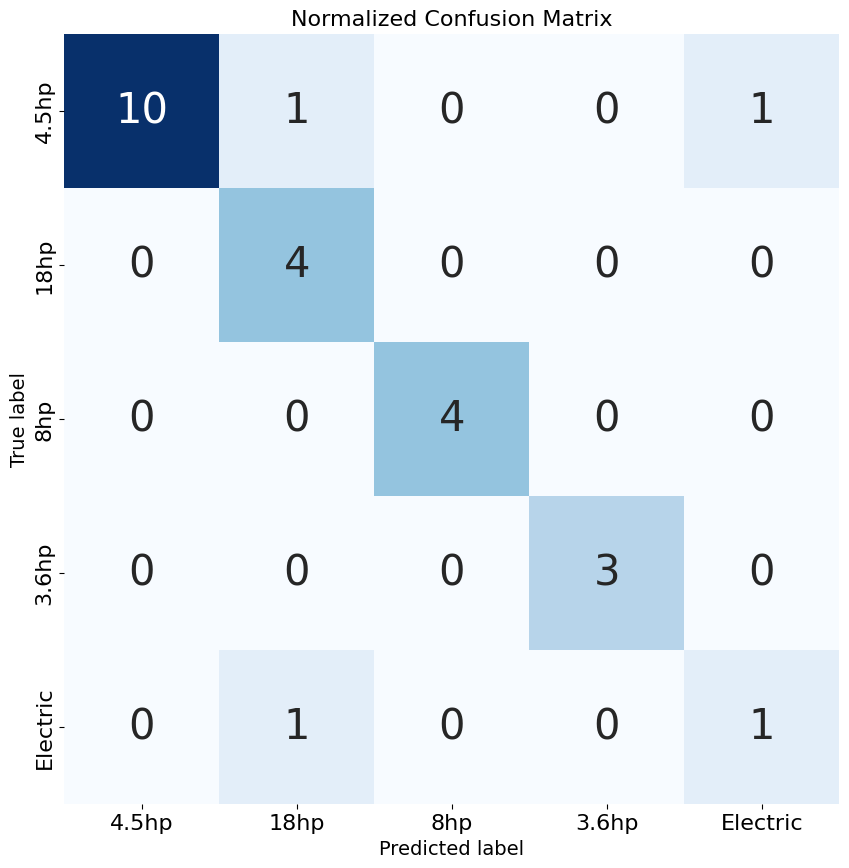

In [32]:
plot_confusion_matrix(y_true, y_pred, class_names, text_fontsize=30, xlabel_fontsize=14, ylabel_fontsize=14, xtick_labelsize=16, ytick_labelsize=16, title_fontsize=16)

In [8]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=False, # Set to False for a human-readable string output
    zero_division=0,
)

print(report)

              precision    recall  f1-score   support

       4.5hp       1.00      0.83      0.91        12
        18hp       0.67      1.00      0.80         4
         8hp       1.00      1.00      1.00         4
       3.6hp       1.00      1.00      1.00         3
    Electric       0.50      0.50      0.50         2

    accuracy                           0.88        25
   macro avg       0.83      0.87      0.84        25
weighted avg       0.91      0.88      0.88        25

